# Make a KIND-based rollout on detuning data

In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

cur_dir = os.getcwd()
root_dir = os.path.abspath(os.path.join(cur_dir, '..', '..'))
sys.path.append(root_dir)

data_dir = '../../data/kalman'
model_dir = '../../models/kalman'
result_dir = '../../results/kalman'

# --! import Python libraries --!

import numpy as np
import torch
import matplotlib.pyplot as plt
import pandas as pd

import kind
import example_kalman
import util_data
import util_nn

In [2]:
# --! initialize random seed

seeds = [3, 123, 2026, 8192, 65536]
seed = seeds[0]

util_nn.set_seed(seed)

print(f'setting seed {seed}')

setting seed 3


## Load a trained KIND model

In [3]:
parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', data_dir,
        '--file_name', 'kalman',
        '--data_nsample_baseline', '5000',
        '--data_nsample_nom', '144',
        '--data_nsample_exc', '144',
        '--obs_ndim', '1',
        '--act_ndim', '0',
        '--target_ndim', '1',
        '--data_train_size', '0.8',

        '--back_nsample', '96',
        '--fore_nsample', '48',

        '--batch_size', '128',
        '--learning_rate', '0.001',
        '--weight_decay', '0.000001',
        '--nepoch', '800',
        '--patience', '80',
        '--checkpoints', model_dir,

        '--rez_nsample_nom', '48',
        '--rez_nsample_exc', '12',
        '--embed_nom', '{"sin": 3, "cos": 3}',
        '--embed_exc', '{"sin": 5, "cos": 5}',
    ]
)

setpoint = torch.tensor([0.0])

# --! instantiate loaded KIND model
model = kind.model(args)

# --! load trained weights into model
model_path = args.checkpoints + '/' + 'checkpoint.pth'
model.load_state_dict(torch.load(model_path, weights_only=True))

dataset = example_kalman.dataset(args, setpoint, load_normalized=False, extract_windows=False)
model = kind.model_adapter(model, dataset.normalizer)

## Evaluate open-loop forecast of KIND

KIND operates in a lookback$\rightarrow$forecast manner: a 96-sample lookback window provides temporal context for a 48-sample open-loop forecast. This temporal context is important for identifying transient dynamical regimes and anticipating rapid amplitude changes that are not observable from instantaneous measurements alone.

In [4]:
_, _, data_loader = dataset.load(data_type='exc')

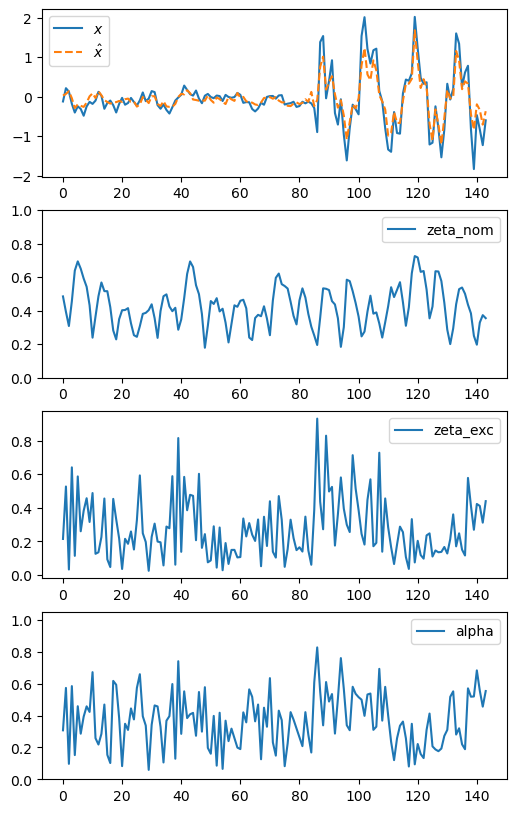

In [5]:
jdata = 13

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        pre = model_o.blend
        u_nom = model_o.zeta_nom
        u_exc = model_o.zeta_exc
        alpha = model_o.alpha

        plt.figure(figsize=(6,10))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :1], label='$x$')
        plt.plot(pre[0, :, :1], linestyle='dashed', label='$\\hat{x}$')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(u_nom[0, :, :1], label='zeta_nom')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(u_exc[0, :, :1], label='zeta_exc')
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(alpha[0, :, :1], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break

## Load detuning trajectory data

In [6]:
data_path = f'{data_dir}/eval.csv'
dataframe = pd.read_csv(data_path, header=None, dtype=np.float32)
traj_true = torch.unsqueeze(torch.from_numpy(dataframe.to_numpy().copy()), 0)

print(f'inf > loaded true trajectory with shape: {traj_true.shape}')

inf > loaded true trajectory with shape: torch.Size([1, 1000, 1])


## Detuning rollout with KIND

During rollout we see no catastrophic divergence over 800 steps with periodic re-anchoring. This suggests that even imperfect decomposition can still regularize recursive dynamics, and the hybrid structure itself provides stabilization benefits. This is important for KIND: exact modeling is not the key, bounded behavior is.

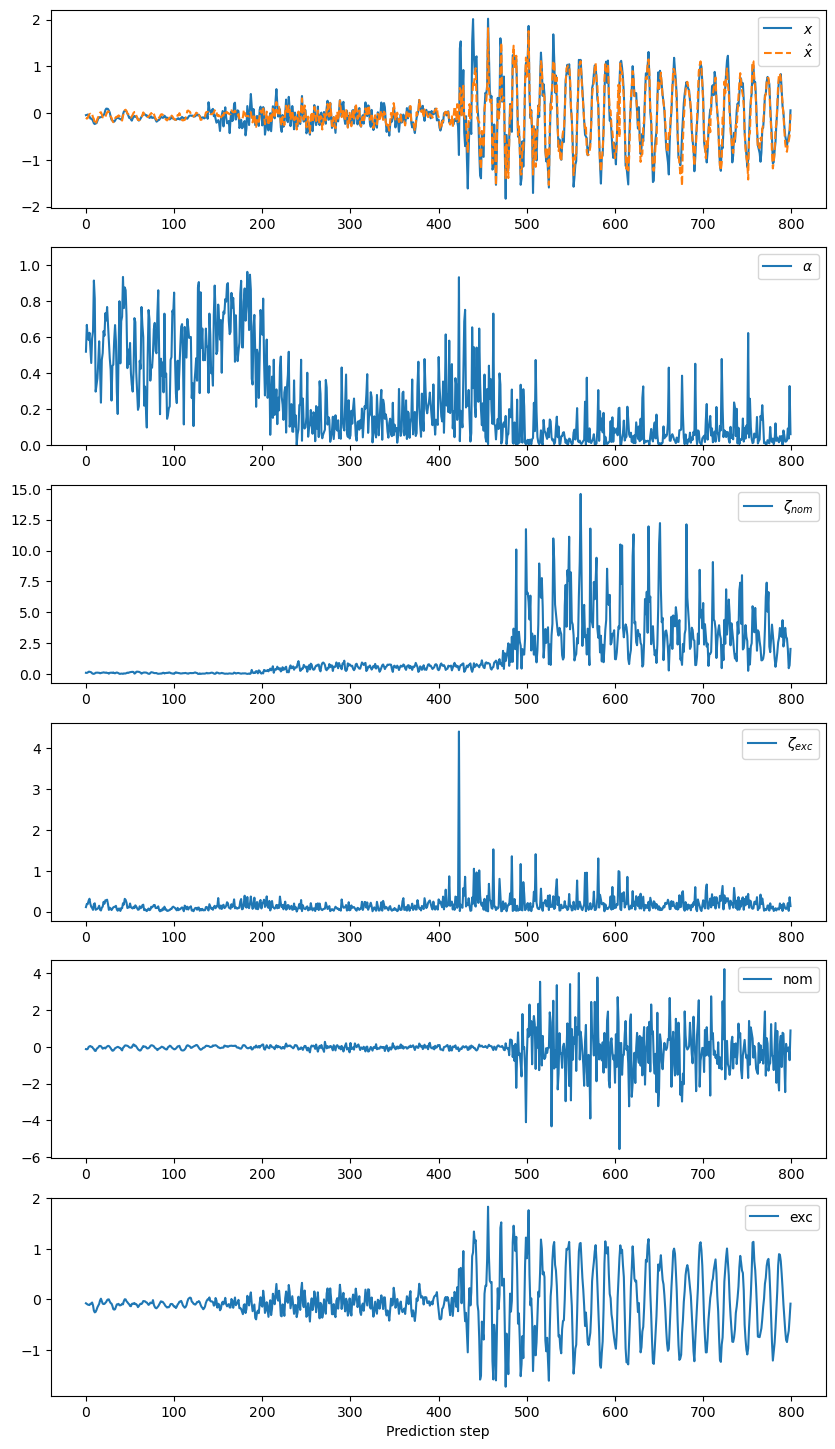

In [7]:
# --! perform model rollout --!

# --! we use this dummy replay just to get access to replay utilities
dummy_replay = example_kalman.replay(s_ndim=args.obs_ndim, a_ndim=args.act_ndim)

# --! rollout length is 300 samples, and model's lookback window is
# --! re-anchored to real data every 20 steps
offset = 0
h = 800
rollout_nsample = 20

next_ss = []
alphas = []
means_nom = []
means_exc = []
zetas_nom = []
zetas_exc = []

back = traj_true[:, offset:offset + args.back_nsample].clone()
true = traj_true[:, offset + args.back_nsample:offset + args.back_nsample + h]

with torch.no_grad():

    for k in range(h):
        if k % rollout_nsample == 0:
            t2 = offset + args.back_nsample + k
            t1 = t2 - args.back_nsample
            back = traj_true[:, t1:t2].clone()

        s = dummy_replay.util.get_s(back)
        model_o = model(back)

        fore = model_o.blend[:, args.back_nsample:]
        next_s = fore[:, :1]
        back = dummy_replay.util.shift_obs(back, next_s)

        alpha = model_o.alpha[:, args.back_nsample:]
        alpha = alpha[:, :1]

        zeta_nom = model_o.zeta_nom[:, args.back_nsample:]
        zeta_nom = zeta_nom[:, :1]

        zeta_exc = model_o.zeta_exc[:, args.back_nsample:]
        zeta_exc = zeta_exc[:, :1]

        mean_nom = model_o.mean_nom[:, args.back_nsample:]
        mean_nom = mean_nom[:, :1]

        mean_exc = model_o.mean_exc[:, args.back_nsample:]
        mean_exc = mean_exc[:, :1]

        next_ss.append(next_s)
        alphas.append(alpha)
        zetas_nom.append(zeta_nom)
        zetas_exc.append(zeta_exc)
        means_nom.append(mean_nom)
        means_exc.append(mean_exc)

    next_ss = torch.cat(next_ss, dim=1)
    alphas = torch.cat(alphas, dim=1)
    zetas_nom = torch.cat(zetas_nom, dim=1)
    zetas_exc = torch.cat(zetas_exc, dim=1)
    means_nom = torch.cat(means_nom, dim=1)
    means_exc = torch.cat(means_exc, dim=1)

    plt.figure(figsize=(10,18))

    plt.subplot(6,1,1)
    plt.plot(true[0, :, 0], label='$x$')
    plt.plot(next_ss[0, :, 0], linestyle='dashed', label='$\\hat{x}$')
    plt.legend()

    plt.subplot(6,1,2)
    plt.plot(alphas[0, :, 0], label='$\\alpha$')
    plt.ylim((0.0, 1.1))
    plt.legend()

    plt.subplot(6,1,3)
    plt.plot(zetas_nom[0, :, 0], label='$\\zeta_{nom}$')
    plt.legend()

    plt.subplot(6,1,4)
    plt.plot(zetas_exc[0, :, 0], label='$\\zeta_{exc}$')
    plt.legend()

    plt.subplot(6,1,5)
    plt.plot(means_nom[0, :, 0], label='nom')
    plt.legend()

    plt.subplot(6,1,6)
    plt.plot(means_exc[0, :, 0], label='exc')
    plt.legend()
    plt.xlabel('Prediction step')

    plt.show()